In [1]:
import pickle
from dataclasses import asdict
from pathlib import Path
import gsw
import seawater as sw
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from tqdm.auto import tqdm
import scipy.stats as stats
from itertools import product
from datetime import datetime as dt

/tmp/ipykernel_194591/2065010725.py:5: UserWarning: The seawater library is deprecated! Please use gsw instead.
  import seawater as sw


In [2]:
from argo_interp.data import data_filter, get_data
from argo_interp.cycle.adapter import PchipAdapter
from argo_interp.cycle.config import ModelKwargs, ModelSettings
from argo_interp.cycle.domain import ModelData, ModelMeta
from argo_interp.cycle.model import Model
from argo_interp.model import CycleModels, CycleData
from lib import (
    GaussianScale,
    WeightConfig,
    build_candidate_query,
    compute_weight_deltas,
    weighted_cycle_prediction,
    plot_desaturated_heatmap,
)

/home/jcherry/Documents/storage/git/argo-data-interpolation/.venv/bin/python: No module named pip


In [3]:
notebook_dir = Path(".")
data_path = notebook_dir / "data"
chart_path = data_path / "charts"
chart_path.mkdir(exist_ok=True, parents=True)

box = [
    80, 99,
    6, 23,
    0, 750,
    "2011-01-01", "2020-12-31",
]

argo_data_path = data_path / "argo_data.pkl"

if argo_data_path.exists():
    ds = pickle.load(open(argo_data_path, "rb"))
else:
    ds = get_data(box, progress=True)
    with argo_data_path.open("wb") as f:
        pickle.dump(ds, f)

In [4]:
ds_filters = [
    ds["PRES_QC"].isin([1, 2]),
    ds["TEMP_QC"].isin([1, 2]),
    ds["PSAL_QC"].isin([1, 2]),
]
ds = data_filter(ds, ds_filters)

In [5]:
settings = ModelSettings(n_folds=5)

In [6]:
models = {}
models_data = {}

cycles = len(ds[["PLATFORM_NUMBER", "CYCLE_NUMBER", "DIRECTION"]].to_dataframe().drop_duplicates())
t = tqdm(ds.groupby(["PLATFORM_NUMBER", "CYCLE_NUMBER", "DIRECTION"]), total=cycles)
for (platform_number, cycle_number, direction), cycle_ds in t:
    pressure = cycle_ds["PRES"].values
    temperature = cycle_ds["TEMP"].values
    salinity = cycle_ds["PSAL"].values

    latitude = cycle_ds["LATITUDE"].values[0]
    longitude = cycle_ds["LONGITUDE"].values[0]
    timestamp = cycle_ds["TIME"].values[0]

    if cycle_ds.sizes['N_POINTS'] < 3:
        continue

    model_data = ModelData(
        pressure=pressure,
        temperature=temperature,
        salinity=salinity,
    ).clean_duplicates("mean")

    model_meta = ModelMeta(
        platform_number=str(int(platform_number)),
        cycle_number=str(int(cycle_number)),
        direction=direction,
        latitude=latitude,
        longitude=longitude,
        timestamp=timestamp,
        profile_pressure=(pressure.min(), pressure.max()),
    )
    cycle_id = model_meta.cycle_id

    linear_model = Model.build(model_meta, model_data, PchipAdapter, settings)
    models[cycle_id] = linear_model
    models_data[cycle_id] = model_data
    t.set_postfix(model_count=len(models))
cycle_models = CycleModels(models)
all_metadata = cycle_models.metadata()

  0%|          | 0/21005 [00:00<?, ?it/s]

In [7]:
SECONDS_PER_YEAR = 365.25 * 24 * 60 * 60
SECONDS_PER_WEEK = 7 * 24 * 60 * 60

dist_rad = 1
dist_border_stdev = 3

year_stdev = 3

season_weeks = 8
season_week_stdev = 3

use_distance_weight = True
use_time_weight = False
use_season_weight = False

weight_config = WeightConfig(
    distance=GaussianScale.from_border(dist_rad, dist_border_stdev),
    time=GaussianScale(year_stdev * SECONDS_PER_YEAR),
    season=GaussianScale.from_border(season_weeks * SECONDS_PER_WEEK, season_week_stdev),
    use_distance=use_distance_weight,
    use_time=use_time_weight,
    use_season=use_season_weight,
)

In [8]:
temp_errors = {}
temp_rmse_vals = {}
sal_errors = {}
sal_rmse_vals = {}
for cycle_position, cycle_id in enumerate(tqdm(all_metadata.cycle_id)):
    model_data = models_data[cycle_id]
    target_timestamp = pd.Timestamp(all_metadata.timestamp[cycle_position])
    candidate_query = build_candidate_query(
        target_latitude=all_metadata.latitude[cycle_position],
        target_longitude=all_metadata.longitude[cycle_position],
        # target_timestamp=target_timestamp,
        dist_rad=dist_rad,
        # season_weeks=season_weeks,
        exclude_platform_number=all_metadata.platform_number[cycle_position],
    )
    candidate_mask = cycle_models.mask(**candidate_query.to_mask_kwargs())
    candidate_metadata = cycle_models.metadata(candidate_mask)

    if len(candidate_metadata) == 0:
        continue

    weight_deltas = compute_weight_deltas(
        target_latitude=all_metadata.latitude[cycle_position],
        target_longitude=all_metadata.longitude[cycle_position],
        target_timestamp=all_metadata.timestamp[cycle_position],
        candidate_metadata=candidate_metadata,
    )
    total_weight = weight_config.joint_weight(weight_deltas)

    support_mask = (
        (model_data.pressure[:, None] >= candidate_metadata.pressure_min[None, :]) &
        (model_data.pressure[:, None] <= candidate_metadata.pressure_max[None, :])
    ).any(axis=1)

    if not np.any(support_mask):
        continue

    active_pressure = model_data.pressure[support_mask]
    active_temperature = model_data.temperature[support_mask]
    active_salinity = model_data.salinity[support_mask]

    interpolates = cycle_models.interpolate(active_pressure, mask=candidate_mask)
    predict_temperature, predict_salinity = weighted_cycle_prediction(interpolates, total_weight)

    predict_temp = pd.Series(
        predict_temperature,
        index=active_pressure,
        name="temperature",
    )
    predict_sal = pd.Series(
        predict_salinity,
        index=active_pressure,
        name="salinity",
    )

    temp_error = active_temperature - predict_temp
    sal_error = active_salinity - predict_sal

    temp_errors[cycle_id] = temp_error
    sal_errors[cycle_id] = sal_error

    temp_rmse = np.sqrt((temp_error ** 2).mean())
    sal_rmse = np.sqrt((sal_error ** 2).mean())

    temp_rmse_vals[cycle_id] = temp_rmse
    sal_rmse_vals[cycle_id] = sal_rmse

temp_errors_straight = pd.concat(temp_errors.values(), axis=0)
sal_errors_straight = pd.concat(sal_errors.values(), axis=0)
temp_rmse_vals = pd.Series(temp_rmse_vals)
sal_rmse_vals = pd.Series(sal_rmse_vals)

  0%|          | 0/20986 [00:00<?, ?it/s]

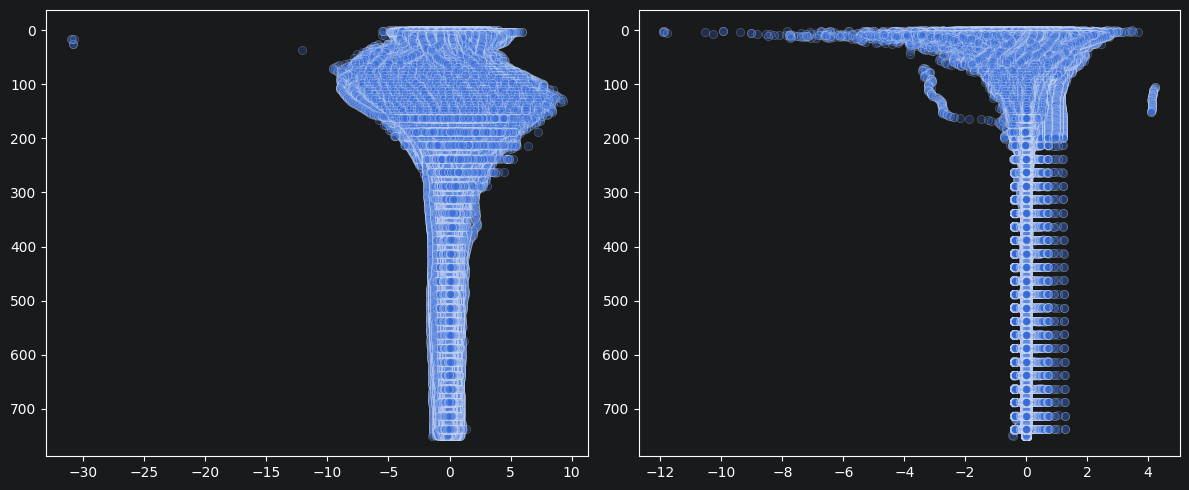

In [9]:
fig, ax = plt.subplots(ncols=2, figsize=(12, 5))

sns.scatterplot(x=temp_errors_straight.values, y=temp_errors_straight.index.values, ax=ax[0], alpha=0.25)
ax[0].invert_yaxis()

sns.scatterplot(x=sal_errors_straight.values, y=sal_errors_straight.index.values, ax=ax[1], alpha=0.25)
ax[1].invert_yaxis()

fig.tight_layout()

In [10]:
temp_rmse_vals.mean(), sal_rmse_vals.mean()

(np.float64(1.124562015865775), np.float64(0.2855208833795319))

In [11]:
lat_resolution = 1e-1
lon_resolution = 1e-1

lat_array = np.arange(box[2], box[3] + lat_resolution, lat_resolution)
lon_array = np.arange(box[0], box[1] + lon_resolution, lon_resolution)

depth_array = np.array([5, 35, 110, 500])

In [12]:
lat_lon_product = list(product(lat_array, lon_array))

In [13]:
anchor_date = dt.now()
results = []
for lat, lon in tqdm(lat_lon_product):
    candidate_query = build_candidate_query(
        target_latitude=lat,
        target_longitude=lon,
        dist_rad=dist_rad,
    )
    candidate_mask = cycle_models.mask(**candidate_query.to_mask_kwargs())

    if candidate_mask.sum() == 0:
        continue

    candidate_metadata = cycle_models.metadata(candidate_mask)

    weight_deltas = compute_weight_deltas(
        target_latitude=lat,
        target_longitude=lon,
        target_timestamp=np.datetime64(anchor_date),
        candidate_metadata=candidate_metadata,
    )
    total_weight = weight_config.joint_weight(weight_deltas)
    scaled_weight = total_weight / total_weight.sum()

    interpolates = cycle_models.interpolate(depth_array, mask=candidate_mask)
    predict_temperature, predict_salinity = weighted_cycle_prediction(interpolates, total_weight)

    interp_errors = cycle_models.interp_error(depth_array, mask=candidate_mask)
    interp_var = CycleData(
        temperature=interp_errors.temperature**2,
        salinity=interp_errors.salinity**2,
    )
    var_temperature, var_salinity = weighted_cycle_prediction(interp_var, total_weight**2)

    c1 = sw.svel(predict_salinity, predict_temperature, depth_array)

    SA = gsw.SA_from_SP(predict_salinity, depth_array, lon, lat)
    CT = gsw.CT_from_t(SA, predict_temperature, depth_array)
    c2 = gsw.sound_speed(SA, CT, depth_array)

    results.append({'latitude': lat, 'longitude': lon,
                    'temp_val': predict_temperature,
                    'temp_var': var_temperature,
                    'sal_val': predict_salinity,
                    'sal_var': var_salinity,
                    'sound_speed_eos80': c1,
                    'sound_speed_teos10': c2,
                    'support': total_weight.sum()})

  0%|          | 0/32661 [00:00<?, ?it/s]

/home/jcherry/Documents/storage/git/argo-data-interpolation/research/underwater-acoustics/notebooks/lib/prediction.py:11: RuntimeWarning: invalid value encountered in divide
  return weighted_sum / weight_sum
/home/jcherry/Documents/storage/git/argo-data-interpolation/research/underwater-acoustics/notebooks/lib/prediction.py:11: RuntimeWarning: invalid value encountered in divide
  return weighted_sum / weight_sum
/home/jcherry/Documents/storage/git/argo-data-interpolation/research/underwater-acoustics/notebooks/lib/prediction.py:11: RuntimeWarning: invalid value encountered in divide
  return weighted_sum / weight_sum
/home/jcherry/Documents/storage/git/argo-data-interpolation/research/underwater-acoustics/notebooks/lib/prediction.py:11: RuntimeWarning: invalid value encountered in divide
  return weighted_sum / weight_sum
/home/jcherry/Documents/storage/git/argo-data-interpolation/research/underwater-acoustics/notebooks/lib/prediction.py:11: RuntimeWarning: invalid value encountered 

In [43]:
idx = 2
chart_data = pd.DataFrame([{
    'latitude': result['latitude'],
    'longitude': result['longitude'],
    'temperature': result['temp_val'][idx],
    'temp_var': result['temp_var'][idx],
    'salinity': result['sal_val'][idx],
    'sal_var': result['sal_var'][idx],
    'sound_speed_eos80': result['sound_speed_eos80'][idx],
    'sound_speed_teos10': result['sound_speed_teos10'][idx],
    'support': result['support'],
} for result in results])

In [46]:
chart_data.pivot(index='latitude', columns='longitude', values='temp_var').mean().mean()

np.float64(0.1205647464441264)

In [41]:
temp_matrix = chart_data.pivot(index='latitude', columns='longitude', values='temperature')
sal_matrix = chart_data.pivot(index='latitude', columns='longitude', values='salinity')
sound_eos80 = chart_data.pivot(index='latitude', columns='longitude', values='sound_speed_eos80')
sound_teos10 = chart_data.pivot(index='latitude', columns='longitude', values='sound_speed_teos10')
support_matrix = chart_data.pivot(index='latitude', columns='longitude', values='support')

tau = 40
support_matrix = 1 - np.exp(-support_matrix / tau)

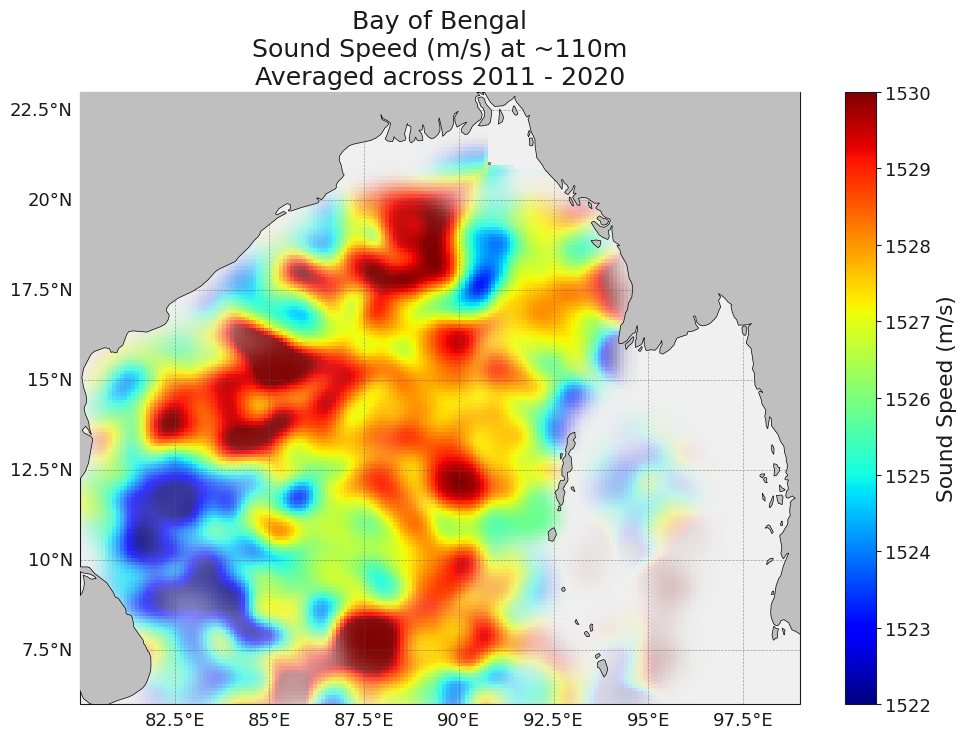

In [42]:
import cartopy.crs as ccrs

light_mode = True
neutral_color = (0.94, 0.94, 0.94) if light_mode else (0.25, 0.25, 0.25)
land_color = "0.75" if light_mode else "0.85"
val_min_max = (1522.0, 1530.0)

fig, ax = plt.subplots(
    figsize=(10, 7.5),
    subplot_kw={"projection": ccrs.PlateCarree()},
)
fig.patch.set_facecolor("white" if light_mode else (0.1, 0.1, 0.1))

_ = plot_desaturated_heatmap(
    values=sound_eos80,
    value_vmin=val_min_max[0], value_vmax=val_min_max[1],
    standard_error=support_matrix,
    title="Bay of Bengal"
          "\nSound Speed (m/s) at ~110m"
          "\nAveraged across 2011 - 2020",
    cbar_label="Sound Speed (m/s)",
    cmap='jet',
    add_colorbar=True,
    ax=ax,
    neutral_color=neutral_color,
    light_mode=light_mode,
    add_gridlines=True,
    gridline_labels=True,
    add_land=True,
    land_color=land_color,
    add_coastline=True,
    extent=(80, 99, 6, 23),
    font_scale=1.3,
)

fig.tight_layout()

fig.savefig(chart_path / 'jana_remake_image.jpg', facecolor=fig.get_facecolor(),
            dpi=300)